In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [84]:

EPN612_FOLDER = '../data/raw/emg_epn_612/EMG-EPN612 Dataset/EMG-EPN612 Dataset'
TRAINING_FOLDER = EPN612_FOLDER + '/trainingJSON'
USER1_JSON = TRAINING_FOLDER + '/user1/user1.json'
#data/raw/emg_epn_612/EMG-EPN612 Dataset/EMG-EPN612 Dataset/trainingJSON/user1/user1.json

df = pd.read_json(USER1_JSON)
df.head(50)

,generalInfo,userInfo,synchronizationGesture,trainingSamples,testingSamples
deviceModel,Myo Armband,NaN,NaN,NaN,NaN
samplingFrequencyInHertz,200,NaN,NaN,NaN,NaN
recordingTimeInSeconds,5,NaN,NaN,NaN,NaN
repetitionsForSynchronizationGesture,5,NaN,NaN,NaN,NaN
myoPredictionLabel,"{'noGesture': 0, 'fist': 1, 'waveIn': 2, 'wave...",NaN,NaN,NaN,NaN
name,NaN,user1,NaN,NaN,NaN
age,NaN,19,NaN,NaN,NaN
gender,NaN,man,NaN,NaN,NaN
occupation,NaN,student,NaN,NaN,NaN
ethnicGroup,NaN,latin,NaN,NaN,NaN


In [85]:
trimmed = df.iloc[17:][['trainingSamples', 'testingSamples']]
trimmed.head()

,trainingSamples,testingSamples
idx_1,"{'startPointforGestureExecution': 466, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_2,"{'startPointforGestureExecution': 489, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_3,"{'startPointforGestureExecution': 173, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_4,"{'startPointforGestureExecution': 373, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_5,"{'startPointforGestureExecution': 529, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."


In [86]:
ssamp1 = pd.Series(trimmed['trainingSamples'][25])
ssamp1

/var/folders/dk/xl3zmt8560j1mg4qqp6f29280000gn/T/ipykernel_6527/1046123550.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ssamp1 = pd.Series(trimmed['trainingSamples'][25])


groundTruth                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
groundTruthIndex                                                        [529, 716]
startPointforGestureExecution                                                  236
myoDetection                     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
gestureName                                                                   fist
quaternion                       {'w': [0.32430000000000003, 0.3239, 0.32370000...
emg                              {'ch1': [2, 0, -2, 1, 5, -3, -3, 0, -2, -1, -1...
gyroscope                        {'x': [-1.6875, -2.4375, -0.625, 0.125, 0.9375...
accelerometer                    {'x': [0.050800000000000005, 0.0356, 0.0464000...
dtype: object

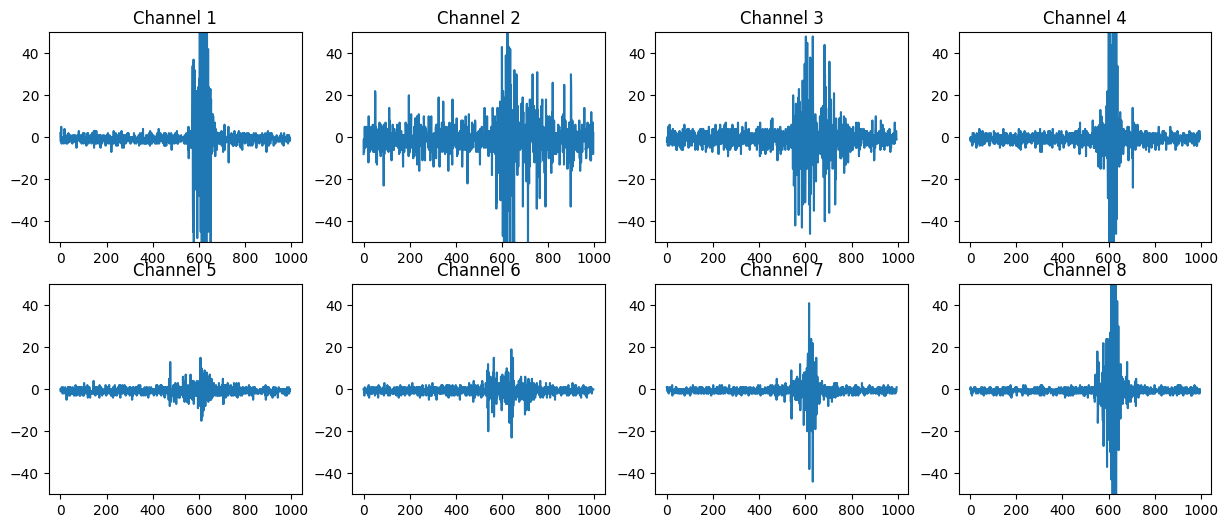

In [92]:
demg1 = ssamp1.emg
i=0
fig, ax = plt.subplots(2, 4, figsize=(15, 6))
for channel in demg1.keys():
    sch = pd.Series(demg1.get(channel))
    subplt = ax[math.floor(i/4), i%4]
    subplt.plot(sch)
    subplt.set_ylim(-50, 50)
    subplt.set_title(f"Channel {i+1}")
    i+=1



Found 306 participant files. Starting streaming average...
Using only trainingJSON; active gestures require valid ground-truth intervals.

Reading trainingJSON: 306 users
[  1/306] trainingJSON user   1/306 | 300 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.0 min elapsed
[ 10/306] trainingJSON user  10/306 | 3,000 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.1 min elapsed
[ 20/306] trainingJSON user  20/306 | 6,000 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.1 min elapsed
[ 30/306] trainingJSON user  30/306 | 9,000 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.2 min elapsed
[ 40/306] trainingJSON user  40/306 | 12,000 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.2 min elapsed
[ 50/306] trainingJSON user  50/306 | 15,000 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.3 min elapsed
[ 60/306] trainingJSON user  60/306 | 18,000 usable trials | 0 unlabeled skipped | 0 invalid skipped | 0.3 min elapsed
[ 

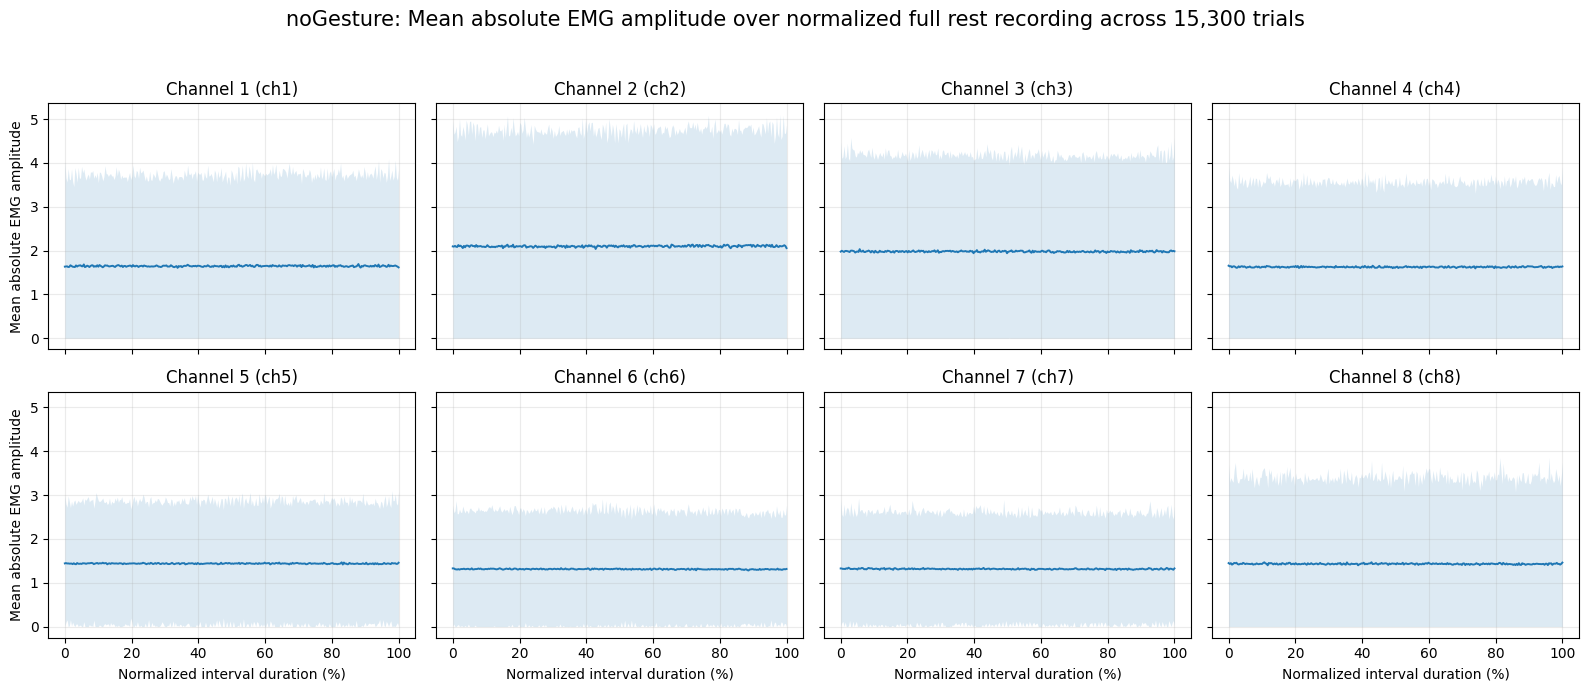

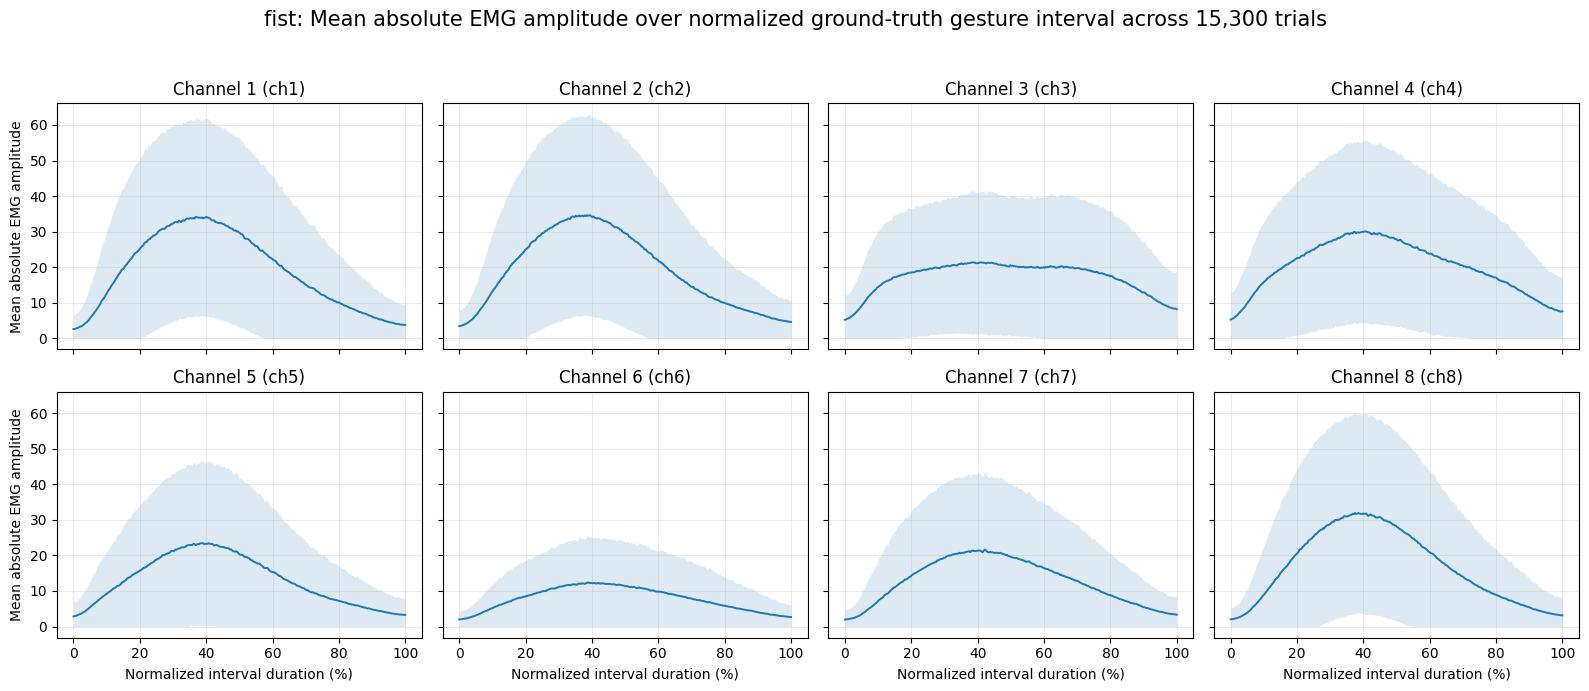

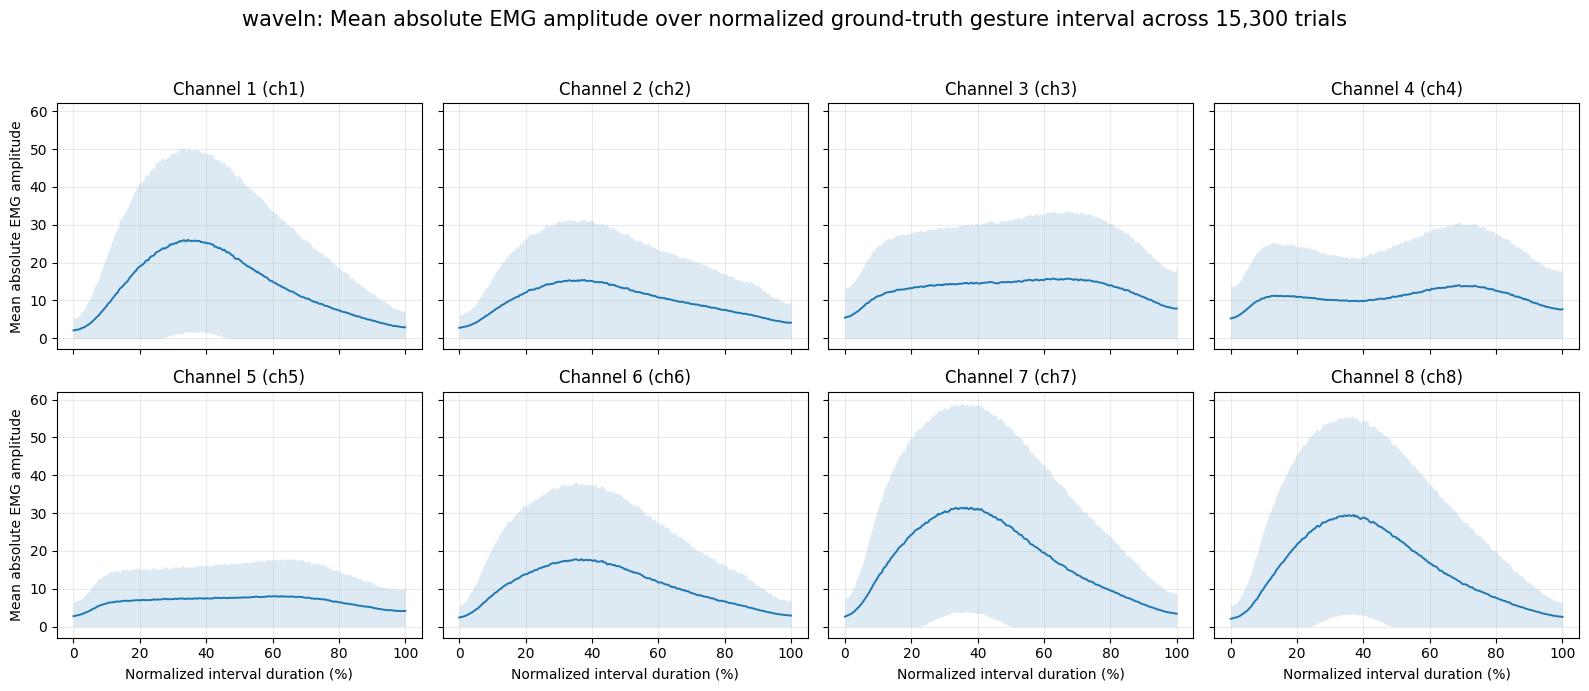

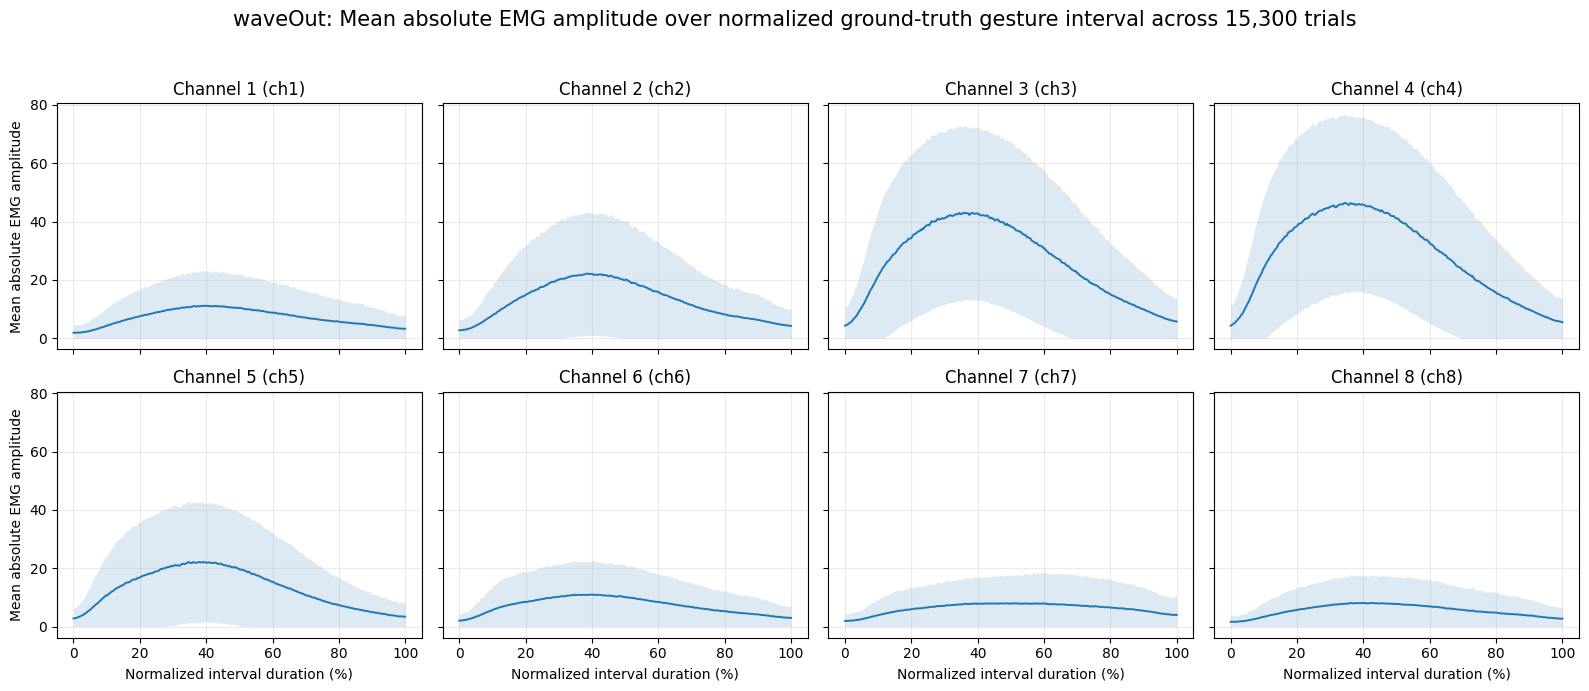

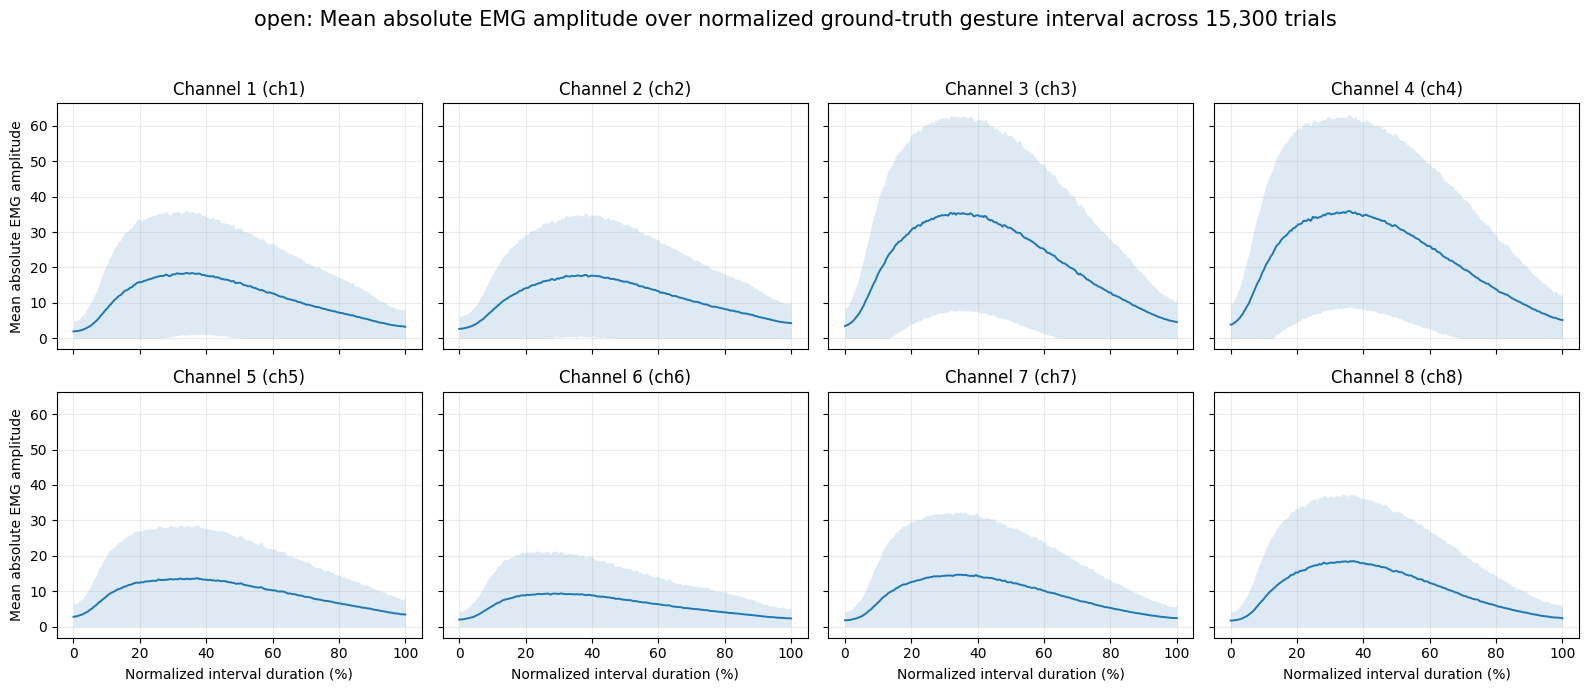

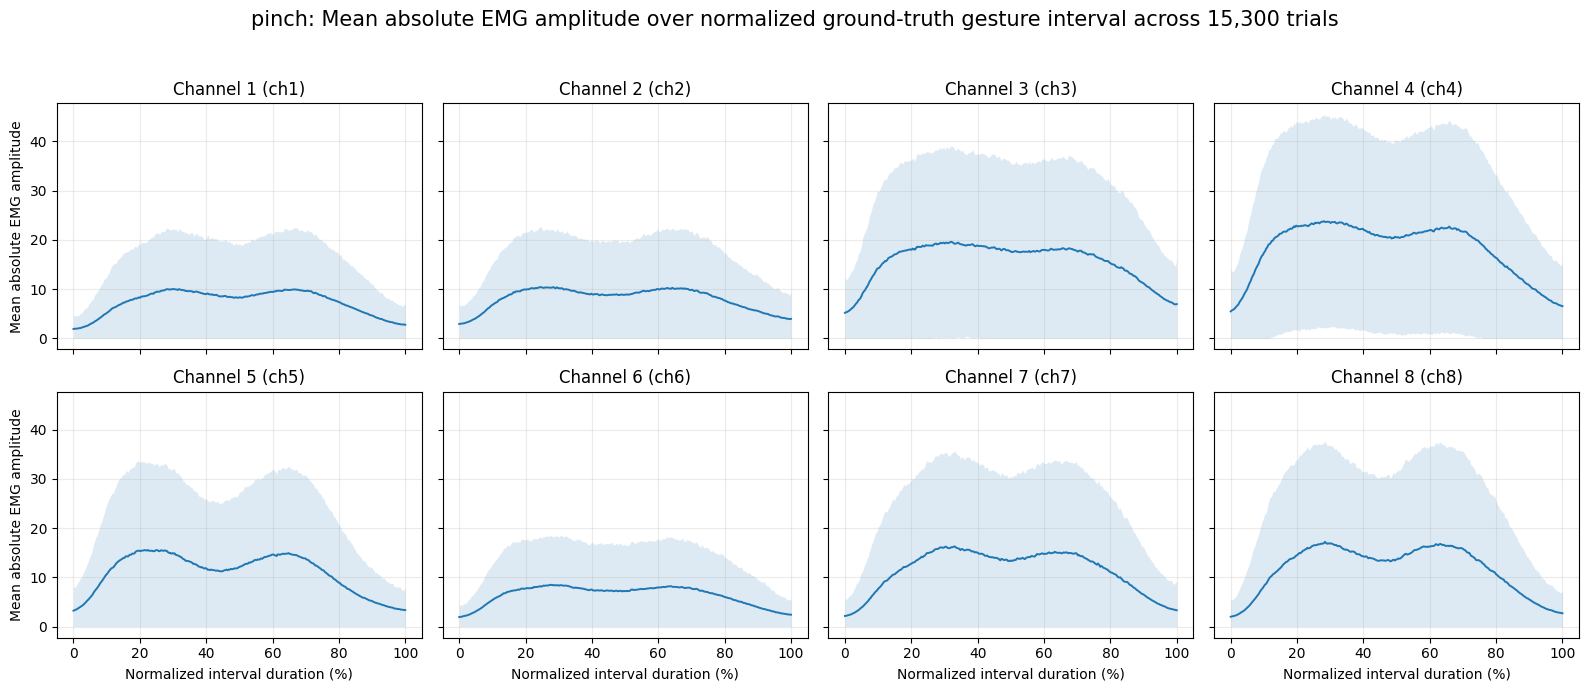

In [12]:
# Average duration-normalized EMG traces for every channel and gesture.
#
# Raw surface EMG is bipolar, so a signed average can cancel toward zero.
# Mean absolute EMG preserves the average activation shape; set this to False
# if you specifically want the literal signed sample-by-sample average.
AVERAGE_ABSOLUTE_EMG = True
NORMALIZED_POINTS = 300
MIN_SEGMENT_SAMPLES = 20
SHOW_STANDARD_DEVIATION = True
PROGRESS_EVERY_N_USERS = 10

import json
import time
from collections import Counter
from pathlib import Path

import numpy as np

dataset_root = Path(EPN612_FOLDER)
channels = [f'ch{i}' for i in range(1, 9)]
gesture_order = ['noGesture', 'fist', 'waveIn', 'waveOut', 'open', 'pinch']
# Use only the fully annotated development cohort. Both sections below are
# labeled and contain ground-truth intervals for the five active gestures.
group_sections = {'trainingJSON': ('trainingSamples', 'testingSamples')}

def user_number(path):
    return int(path.parent.name.removeprefix('user'))

files_by_group = {
    group: sorted((dataset_root / group).glob('user*/*.json'), key=user_number)
    for group in group_sections
}
total_files = sum(len(paths) for paths in files_by_group.values())
print(f'Found {total_files} participant files. Starting streaming average...', flush=True)
print(
    'Using only trainingJSON; active gestures require valid ground-truth intervals.',
    flush=True,
)

# These fixed-size accumulators stay small; only one participant JSON is held in memory.
signal_sums = {}
signal_square_sums = {}
trial_counts = Counter()
sampling_rates = set()
used_trials = 0
unlabeled_trials = 0
skipped_trials = Counter()
processed_files = 0
started_at = time.perf_counter()

for group, sections in group_sections.items():
    paths = files_by_group[group]
    print(f'\nReading {group}: {len(paths)} users', flush=True)

    for group_file_index, json_path in enumerate(paths, start=1):
        with json_path.open(encoding='utf-8') as file:
            document = json.load(file)

        file_sampling_rate_hz = float(document['generalInfo']['samplingFrequencyInHertz'])
        sampling_rates.add(file_sampling_rate_hz)

        for section in sections:
            for trial in document.get(section, {}).values():
                gesture = trial.get('gestureName')
                if gesture is None:
                    unlabeled_trials += 1
                    continue

                try:
                    channel_lengths = [len(trial['emg'][channel]) for channel in channels]
                except (KeyError, TypeError):
                    skipped_trials['missing EMG channel'] += 1
                    continue
                if len(set(channel_lengths)) != 1:
                    skipped_trials['unequal EMG channel lengths'] += 1
                    continue

                try:
                    signal = np.asarray(
                        [trial['emg'][channel] for channel in channels],
                        dtype=np.float64,
                    )
                except (TypeError, ValueError):
                    skipped_trials['invalid EMG values'] += 1
                    continue
                if not np.isfinite(signal).all():
                    skipped_trials['non-finite EMG values'] += 1
                    continue
                sample_count = signal.shape[1]

                if gesture == 'noGesture':
                    # The complete noGesture recording is a valid rest interval.
                    segment = signal
                else:
                    ground_truth_index = trial.get('groundTruthIndex')
                    ground_truth = trial.get('groundTruth')
                    if not isinstance(ground_truth_index, list) or len(ground_truth_index) != 2:
                        skipped_trials['missing groundTruthIndex'] += 1
                        continue
                    if not isinstance(ground_truth, list) or len(ground_truth) != sample_count:
                        skipped_trials['missing or mismatched groundTruth'] += 1
                        continue

                    start_index_1based, end_index_1based = map(int, ground_truth_index)
                    # groundTruthIndex is 1-based with an inclusive end index.
                    if not (1 <= start_index_1based <= end_index_1based <= sample_count):
                        skipped_trials['invalid groundTruthIndex'] += 1
                        continue
                    start_index = start_index_1based - 1
                    end_index_exclusive = end_index_1based

                    active_indexes = np.flatnonzero(np.asarray(ground_truth) != 0)
                    if (
                        active_indexes.size == 0
                        or active_indexes[0] != start_index
                        or active_indexes[-1] != end_index_exclusive - 1
                    ):
                        skipped_trials['inconsistent ground-truth annotations'] += 1
                        continue
                    segment = signal[:, start_index:end_index_exclusive]

                if segment.shape[1] < MIN_SEGMENT_SAMPLES:
                    skipped_trials['segment too short'] += 1
                    continue
                if AVERAGE_ABSOLUTE_EMG:
                    segment = np.abs(segment)

                # Normalize variable-duration gestures to a common 0-100% phase axis.
                source_phase = np.linspace(0.0, 1.0, segment.shape[1])
                normalized_phase = np.linspace(0.0, 1.0, NORMALIZED_POINTS)
                normalized_signal = np.vstack([
                    np.interp(normalized_phase, source_phase, channel_signal)
                    for channel_signal in segment
                ])

                if gesture not in signal_sums:
                    signal_sums[gesture] = np.zeros((len(channels), NORMALIZED_POINTS))
                    signal_square_sums[gesture] = np.zeros((len(channels), NORMALIZED_POINTS))

                signal_sums[gesture] += normalized_signal
                signal_square_sums[gesture] += normalized_signal ** 2
                trial_counts[gesture] += 1
                used_trials += 1

        processed_files += 1
        should_report = (
            group_file_index == 1
            or group_file_index % PROGRESS_EVERY_N_USERS == 0
            or group_file_index == len(paths)
        )
        if should_report:
            elapsed_minutes = (time.perf_counter() - started_at) / 60
            print(
                f'[{processed_files:>3}/{total_files}] {group} user '
                f'{group_file_index:>3}/{len(paths)} | '
                f'{used_trials:,} usable trials | '
                f'{unlabeled_trials:,} unlabeled skipped | '
                f'{sum(skipped_trials.values()):,} invalid skipped | '
                f'{elapsed_minutes:.1f} min elapsed',
                flush=True,
            )

elapsed_minutes = (time.perf_counter() - started_at) / 60
print(f'\nAveraging complete in {elapsed_minutes:.1f} min.', flush=True)
print(f'Usable trials averaged: {used_trials:,}', flush=True)
print(f'Unlabeled trials skipped: {unlabeled_trials:,}', flush=True)
print(f'Invalid annotated trials skipped by reason: {dict(skipped_trials)}', flush=True)
print(f'Trials per gesture: {dict(trial_counts)}', flush=True)

if len(sampling_rates) != 1:
    raise ValueError(f'Expected one sampling rate, found: {sorted(sampling_rates)}')
sampling_rate_hz = sampling_rates.pop()

# Every accepted trial now has the same normalized duration.
average_signals = {}
standard_deviation_signals = {}
for gesture in signal_sums:
    mean_signal = signal_sums[gesture] / trial_counts[gesture]
    variance = np.maximum(
        signal_square_sums[gesture] / trial_counts[gesture] - mean_signal ** 2,
        0,
    )
    average_signals[gesture] = mean_signal
    standard_deviation_signals[gesture] = np.sqrt(variance)

ordered_gestures = [g for g in gesture_order if g in average_signals]
ordered_gestures += sorted(set(average_signals) - set(ordered_gestures))
quantity_name = 'Mean absolute EMG amplitude' if AVERAGE_ABSOLUTE_EMG else 'Mean signed EMG'
normalized_phase_percent = np.linspace(0.0, 100.0, NORMALIZED_POINTS)

for gesture in ordered_gestures:
    mean_emg = average_signals[gesture]
    standard_deviation = standard_deviation_signals[gesture]
    interval_name = 'full rest recording' if gesture == 'noGesture' else 'ground-truth gesture interval'
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)

    for channel_index, (axis, channel) in enumerate(zip(axes.flat, channels)):
        channel_mean = mean_emg[channel_index]
        channel_std = standard_deviation[channel_index]
        axis.plot(normalized_phase_percent, channel_mean, linewidth=1.4, color='C0')
        if SHOW_STANDARD_DEVIATION:
            lower = channel_mean - channel_std
            if AVERAGE_ABSOLUTE_EMG:
                lower = np.maximum(lower, 0)
            axis.fill_between(
                normalized_phase_percent,
                lower,
                channel_mean + channel_std,
                color='C0',
                alpha=0.15,
                linewidth=0,
            )
        axis.set_title(f'Channel {channel_index + 1} ({channel})')
        axis.grid(alpha=0.25)
        if channel_index // 4 == 1:
            axis.set_xlabel('Normalized interval duration (%)')
        if channel_index % 4 == 0:
            axis.set_ylabel(quantity_name)

    fig.suptitle(
        f'{gesture}: {quantity_name} over normalized {interval_name} '
        f'across {trial_counts[gesture]:,} trials',
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


Reading ../data/raw/emg_epn_612/EMG-EPN612 Dataset/EMG-EPN612 Dataset/trainingJSON/user1/user1.json
Participant: user1 | sampling rate: 200 Hz
Processing trainingSamples: 150 recordings
Finished trainingSamples: 150 used, 0 skipped
Processing testingSamples: 150 recordings
Finished testingSamples: 150 used, 0 skipped

Usable recordings averaged: 300
Recordings per gesture: {'noGesture': 50, 'fist': 50, 'open': 50, 'pinch': 50, 'waveIn': 50, 'waveOut': 50}
Skipped by reason: {}


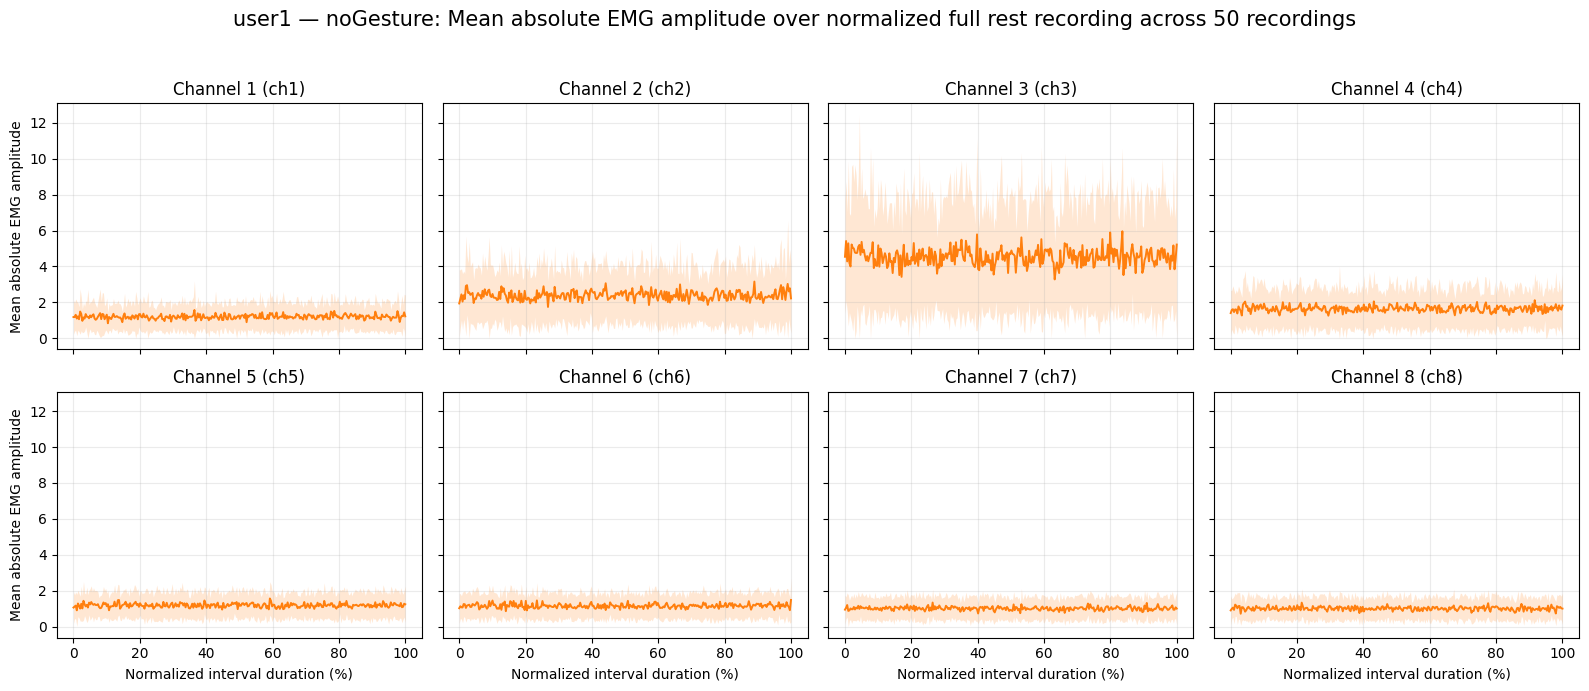

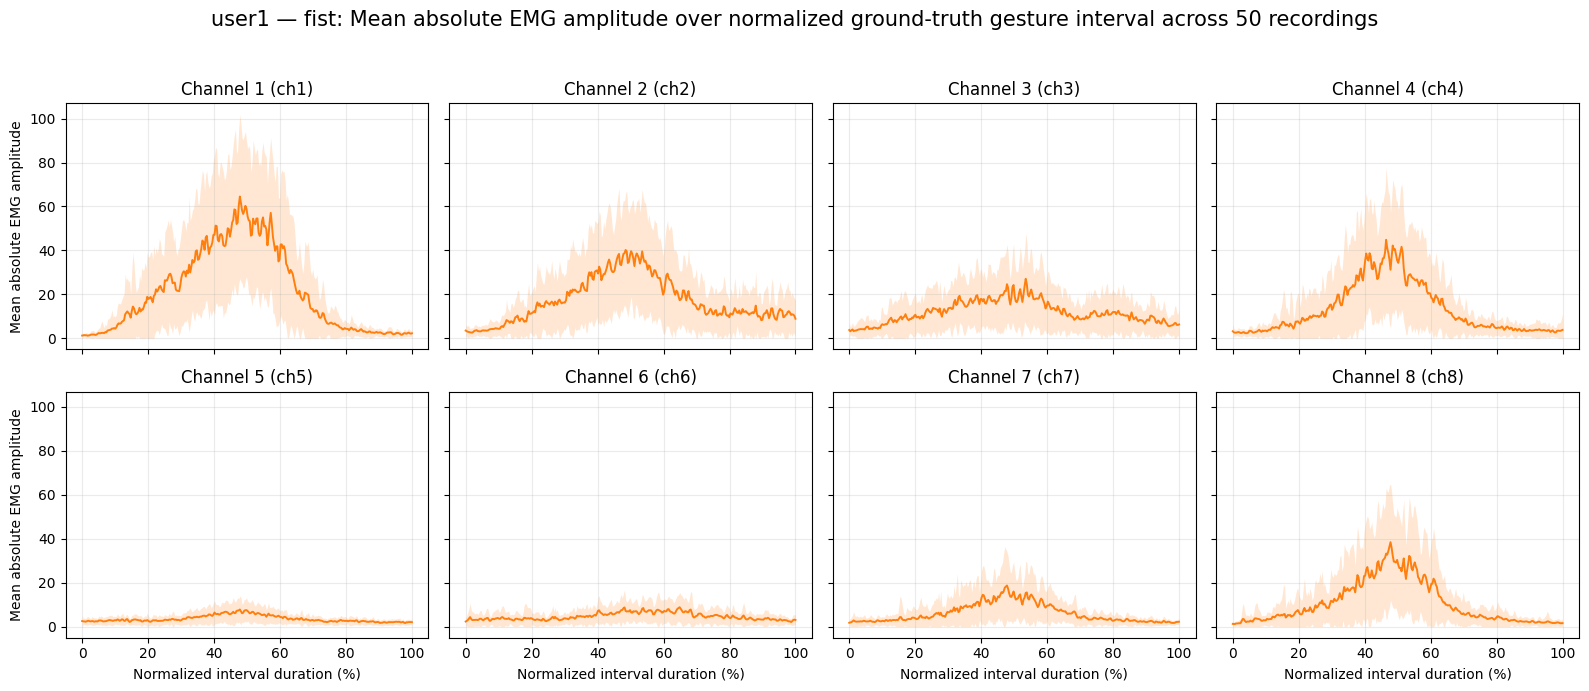

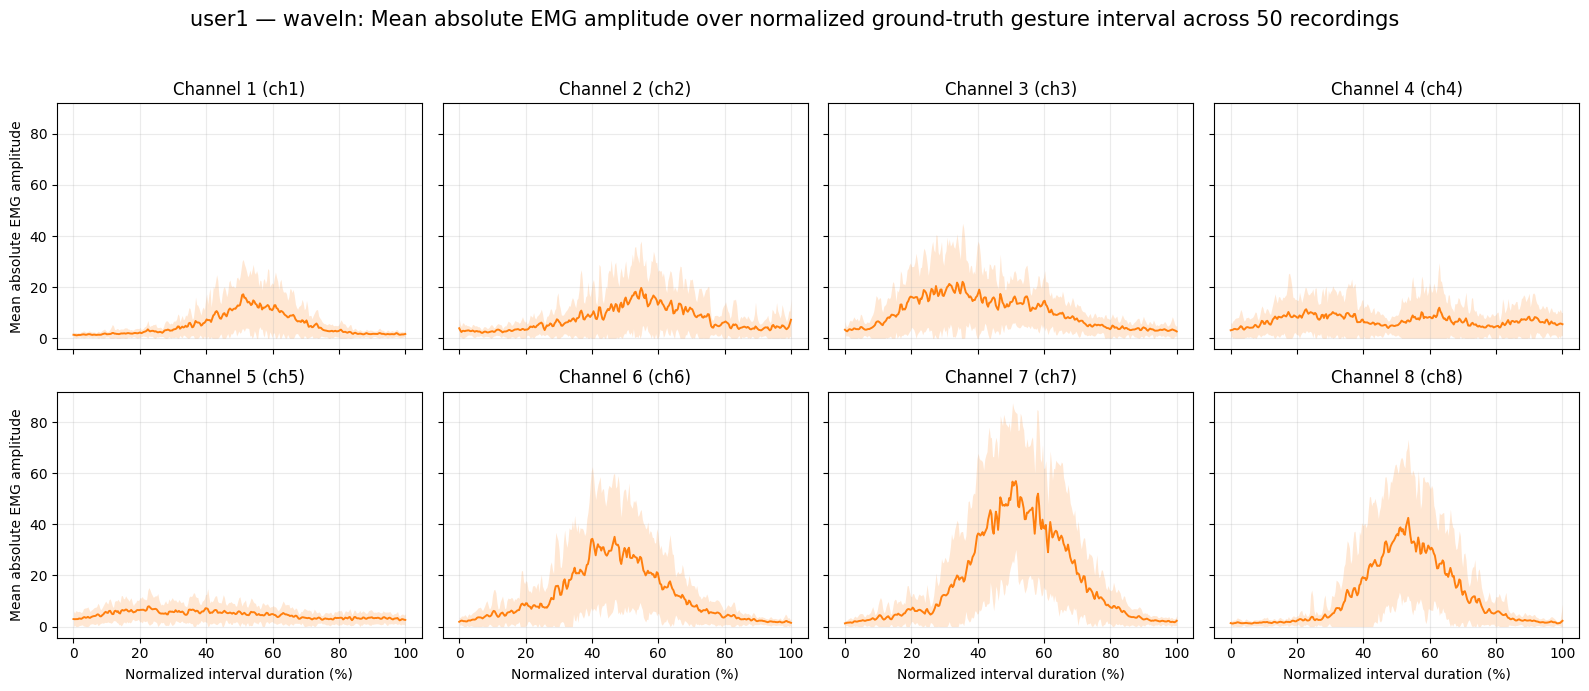

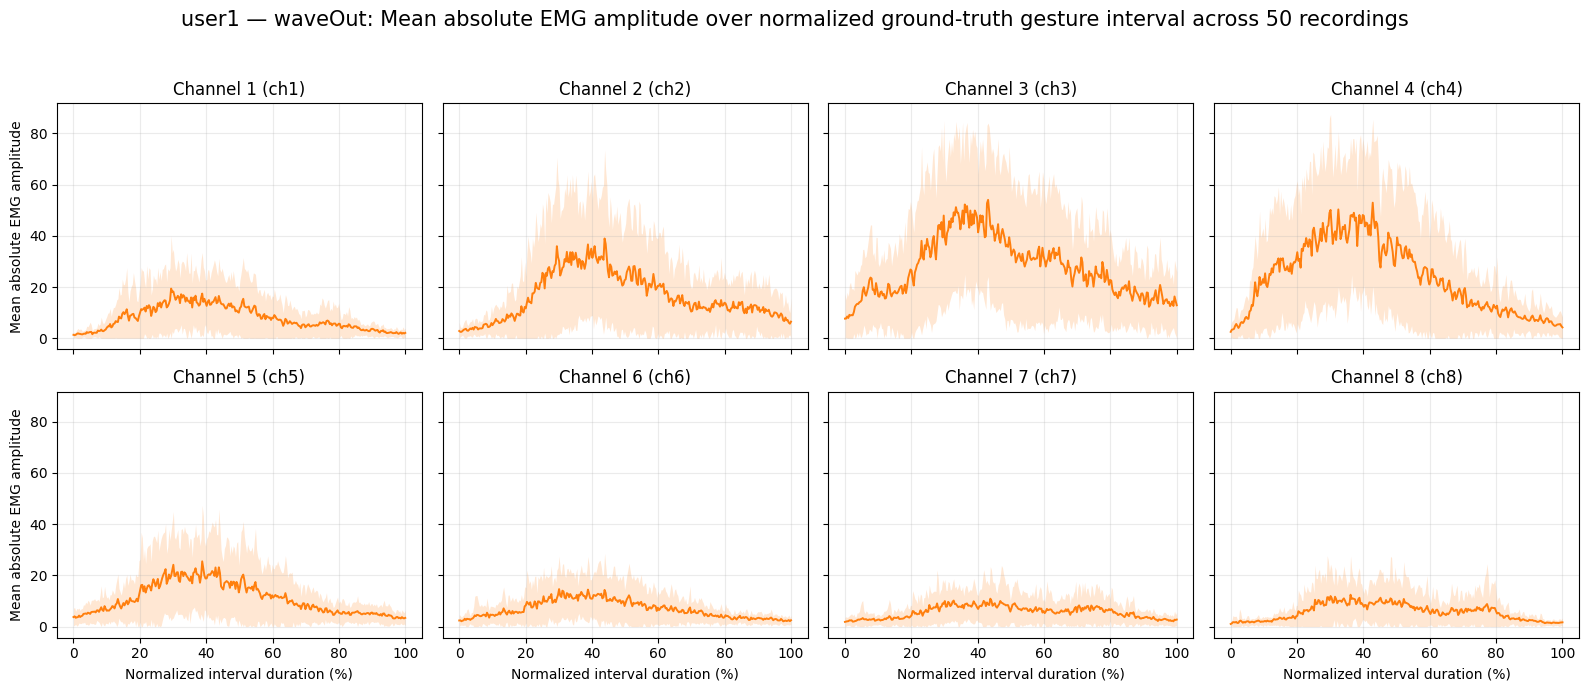

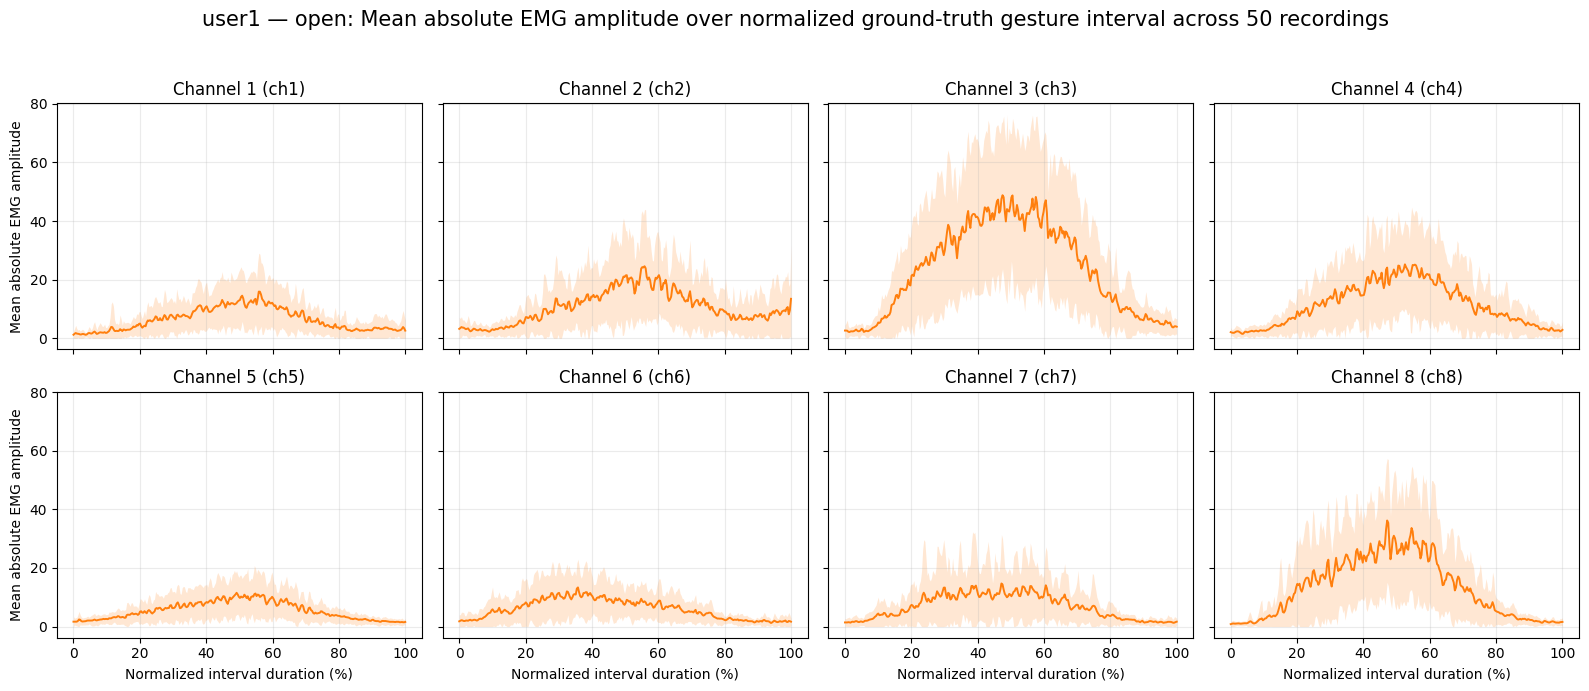

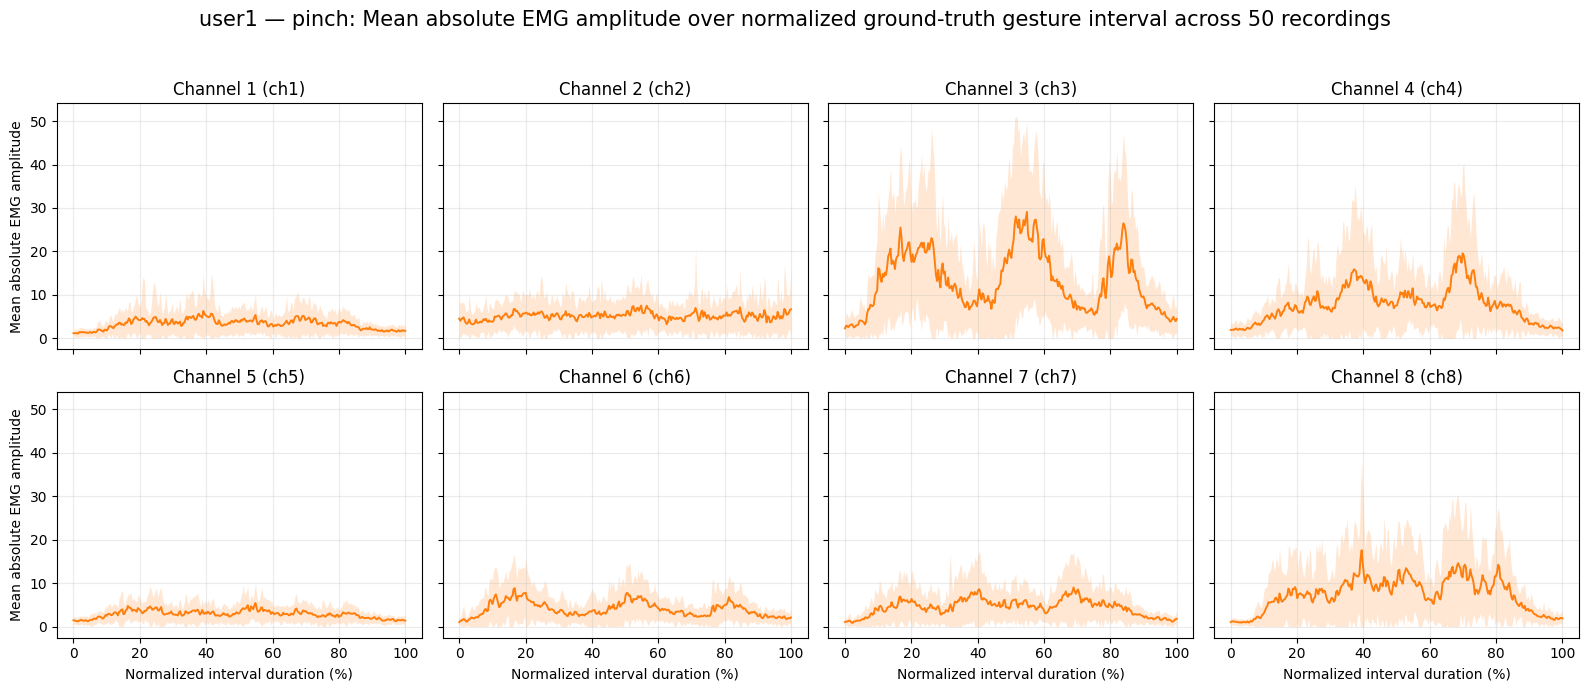

In [15]:
# Repeat the duration-normalized gesture analysis for one participant.
SELECTED_USER = 1
ONE_USER_NORMALIZED_POINTS = 300
ONE_USER_MIN_SEGMENT_SAMPLES = 20
ONE_USER_AVERAGE_ABSOLUTE_EMG = True
ONE_USER_SHOW_STANDARD_DEVIATION = True

import json
from collections import Counter
from pathlib import Path

import numpy as np

one_user_channels = [f'ch{i}' for i in range(1, 9)]
one_user_gesture_order = ['noGesture', 'fist', 'waveIn', 'waveOut', 'open', 'pinch']
one_user_sections = ('trainingSamples', 'testingSamples')
one_user_path = (
    Path(EPN612_FOLDER)
    / 'trainingJSON'
    / f'user{SELECTED_USER}'
    / f'user{SELECTED_USER}.json'
)
if not one_user_path.is_file():
    raise FileNotFoundError(one_user_path)

print(f'Reading {one_user_path}', flush=True)
with one_user_path.open(encoding='utf-8') as file:
    one_user_document = json.load(file)

one_user_name = one_user_document['userInfo']['name']
one_user_sampling_rate_hz = float(
    one_user_document['generalInfo']['samplingFrequencyInHertz']
)
print(
    f'Participant: {one_user_name} | sampling rate: '
    f'{one_user_sampling_rate_hz:g} Hz',
    flush=True,
)

one_user_signal_sums = {}
one_user_signal_square_sums = {}
one_user_trial_counts = Counter()
one_user_skipped_trials = Counter()
one_user_used_trials = 0

for section in one_user_sections:
    section_used_before = one_user_used_trials
    section_skipped_before = sum(one_user_skipped_trials.values())
    section_trials = one_user_document.get(section, {})
    print(f'Processing {section}: {len(section_trials)} recordings', flush=True)

    for trial_id, trial in section_trials.items():
        gesture = trial.get('gestureName')
        if gesture is None:
            one_user_skipped_trials['missing gestureName'] += 1
            continue

        try:
            channel_lengths = [
                len(trial['emg'][channel]) for channel in one_user_channels
            ]
        except (KeyError, TypeError):
            one_user_skipped_trials['missing EMG channel'] += 1
            continue
        if len(set(channel_lengths)) != 1:
            one_user_skipped_trials['unequal EMG channel lengths'] += 1
            continue

        try:
            signal = np.asarray(
                [trial['emg'][channel] for channel in one_user_channels],
                dtype=np.float64,
            )
        except (TypeError, ValueError):
            one_user_skipped_trials['invalid EMG values'] += 1
            continue
        if not np.isfinite(signal).all():
            one_user_skipped_trials['non-finite EMG values'] += 1
            continue

        sample_count = signal.shape[1]
        if gesture == 'noGesture':
            segment = signal
        else:
            ground_truth_index = trial.get('groundTruthIndex')
            ground_truth = trial.get('groundTruth')
            if not isinstance(ground_truth_index, list) or len(ground_truth_index) != 2:
                one_user_skipped_trials['missing groundTruthIndex'] += 1
                continue
            if not isinstance(ground_truth, list) or len(ground_truth) != sample_count:
                one_user_skipped_trials['missing or mismatched groundTruth'] += 1
                continue

            start_index_1based, end_index_1based = map(int, ground_truth_index)
            if not (1 <= start_index_1based <= end_index_1based <= sample_count):
                one_user_skipped_trials['invalid groundTruthIndex'] += 1
                continue
            start_index = start_index_1based - 1
            end_index_exclusive = end_index_1based

            active_indexes = np.flatnonzero(np.asarray(ground_truth) != 0)
            if (
                active_indexes.size == 0
                or active_indexes[0] != start_index
                or active_indexes[-1] != end_index_exclusive - 1
            ):
                one_user_skipped_trials['inconsistent ground-truth annotations'] += 1
                continue
            segment = signal[:, start_index:end_index_exclusive]

        if segment.shape[1] < ONE_USER_MIN_SEGMENT_SAMPLES:
            one_user_skipped_trials['segment too short'] += 1
            continue
        if ONE_USER_AVERAGE_ABSOLUTE_EMG:
            segment = np.abs(segment)

        source_phase = np.linspace(0.0, 1.0, segment.shape[1])
        normalized_phase = np.linspace(0.0, 1.0, ONE_USER_NORMALIZED_POINTS)
        normalized_signal = np.vstack([
            np.interp(normalized_phase, source_phase, channel_signal)
            for channel_signal in segment
        ])

        if gesture not in one_user_signal_sums:
            shape = (len(one_user_channels), ONE_USER_NORMALIZED_POINTS)
            one_user_signal_sums[gesture] = np.zeros(shape)
            one_user_signal_square_sums[gesture] = np.zeros(shape)

        one_user_signal_sums[gesture] += normalized_signal
        one_user_signal_square_sums[gesture] += normalized_signal ** 2
        one_user_trial_counts[gesture] += 1
        one_user_used_trials += 1

    section_used = one_user_used_trials - section_used_before
    section_skipped = (
        sum(one_user_skipped_trials.values()) - section_skipped_before
    )
    print(
        f'Finished {section}: {section_used} used, {section_skipped} skipped',
        flush=True,
    )

print(f'\nUsable recordings averaged: {one_user_used_trials}', flush=True)
print(f'Recordings per gesture: {dict(one_user_trial_counts)}', flush=True)
print(f'Skipped by reason: {dict(one_user_skipped_trials)}', flush=True)

one_user_average_signals = {}
one_user_standard_deviations = {}
for gesture in one_user_signal_sums:
    trial_count = one_user_trial_counts[gesture]
    mean_signal = one_user_signal_sums[gesture] / trial_count
    variance = np.maximum(
        one_user_signal_square_sums[gesture] / trial_count - mean_signal ** 2,
        0,
    )
    one_user_average_signals[gesture] = mean_signal
    one_user_standard_deviations[gesture] = np.sqrt(variance)

ordered_gestures = [
    gesture for gesture in one_user_gesture_order
    if gesture in one_user_average_signals
]
phase_percent = np.linspace(0.0, 100.0, ONE_USER_NORMALIZED_POINTS)
quantity_name = (
    'Mean absolute EMG amplitude'
    if ONE_USER_AVERAGE_ABSOLUTE_EMG
    else 'Mean signed EMG'
)

for gesture in ordered_gestures:
    mean_emg = one_user_average_signals[gesture]
    standard_deviation = one_user_standard_deviations[gesture]
    interval_name = (
        'full rest recording'
        if gesture == 'noGesture'
        else 'ground-truth gesture interval'
    )
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)

    for channel_index, (axis, channel) in enumerate(
        zip(axes.flat, one_user_channels)
    ):
        channel_mean = mean_emg[channel_index]
        channel_std = standard_deviation[channel_index]
        axis.plot(phase_percent, channel_mean, linewidth=1.4, color='C1')
        if ONE_USER_SHOW_STANDARD_DEVIATION:
            lower = channel_mean - channel_std
            if ONE_USER_AVERAGE_ABSOLUTE_EMG:
                lower = np.maximum(lower, 0)
            axis.fill_between(
                phase_percent,
                lower,
                channel_mean + channel_std,
                color='C1',
                alpha=0.18,
                linewidth=0,
            )
        axis.set_title(f'Channel {channel_index + 1} ({channel})')
        axis.grid(alpha=0.25)
        if channel_index // 4 == 1:
            axis.set_xlabel('Normalized interval duration (%)')
        if channel_index % 4 == 0:
            axis.set_ylabel(quantity_name)

    fig.suptitle(
        f'{one_user_name} — {gesture}: {quantity_name} over normalized '
        f'{interval_name} across {one_user_trial_counts[gesture]} recordings',
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


Reading trainingSamples from ../data/raw/emg_epn_612/EMG-EPN612 Dataset/EMG-EPN612 Dataset/trainingJSON/user1/user1.json
Participant: user1 | 150 trainingSamples recordings found
Usable trainingSamples recordings: 150
Recordings per gesture: {'noGesture': 25, 'fist': 25, 'open': 25, 'pinch': 25, 'waveIn': 25, 'waveOut': 25}
Skipped by reason: {}


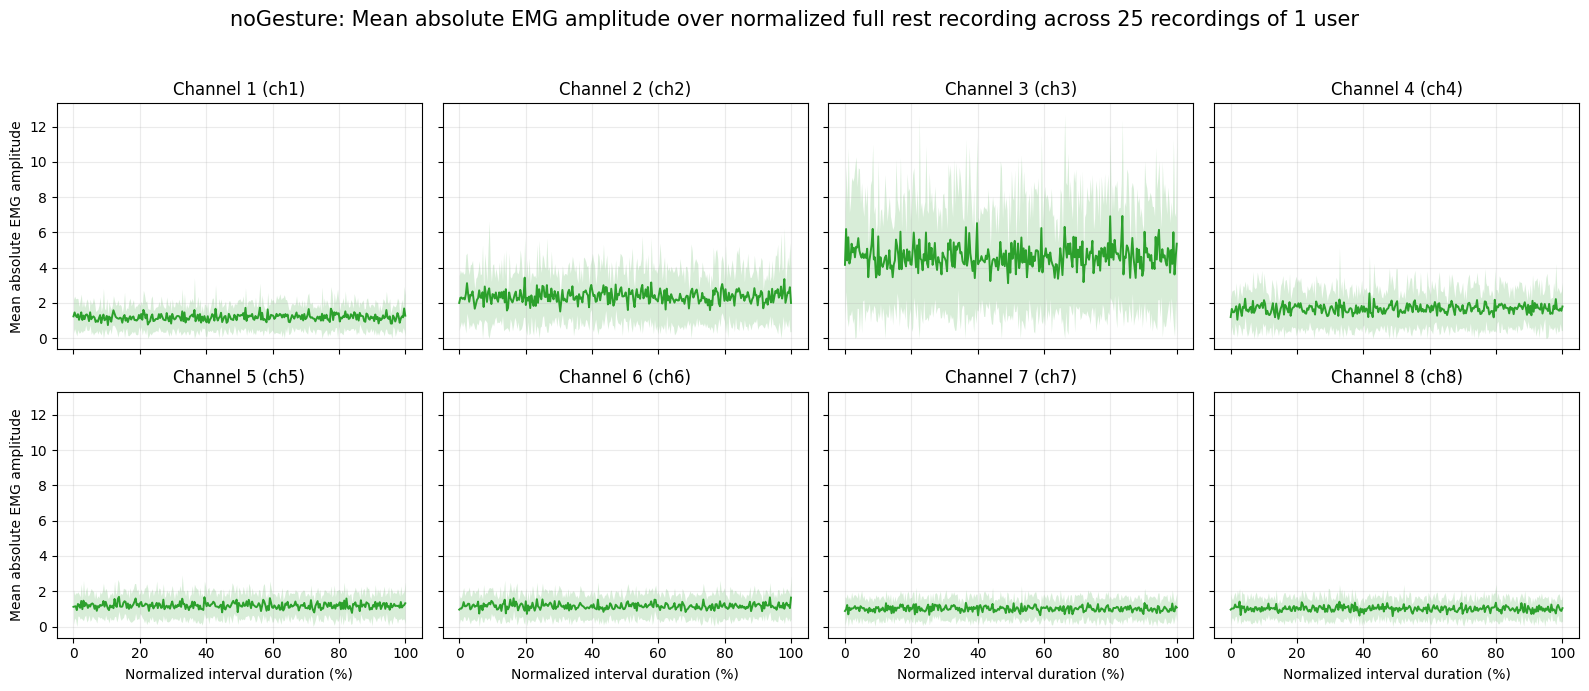

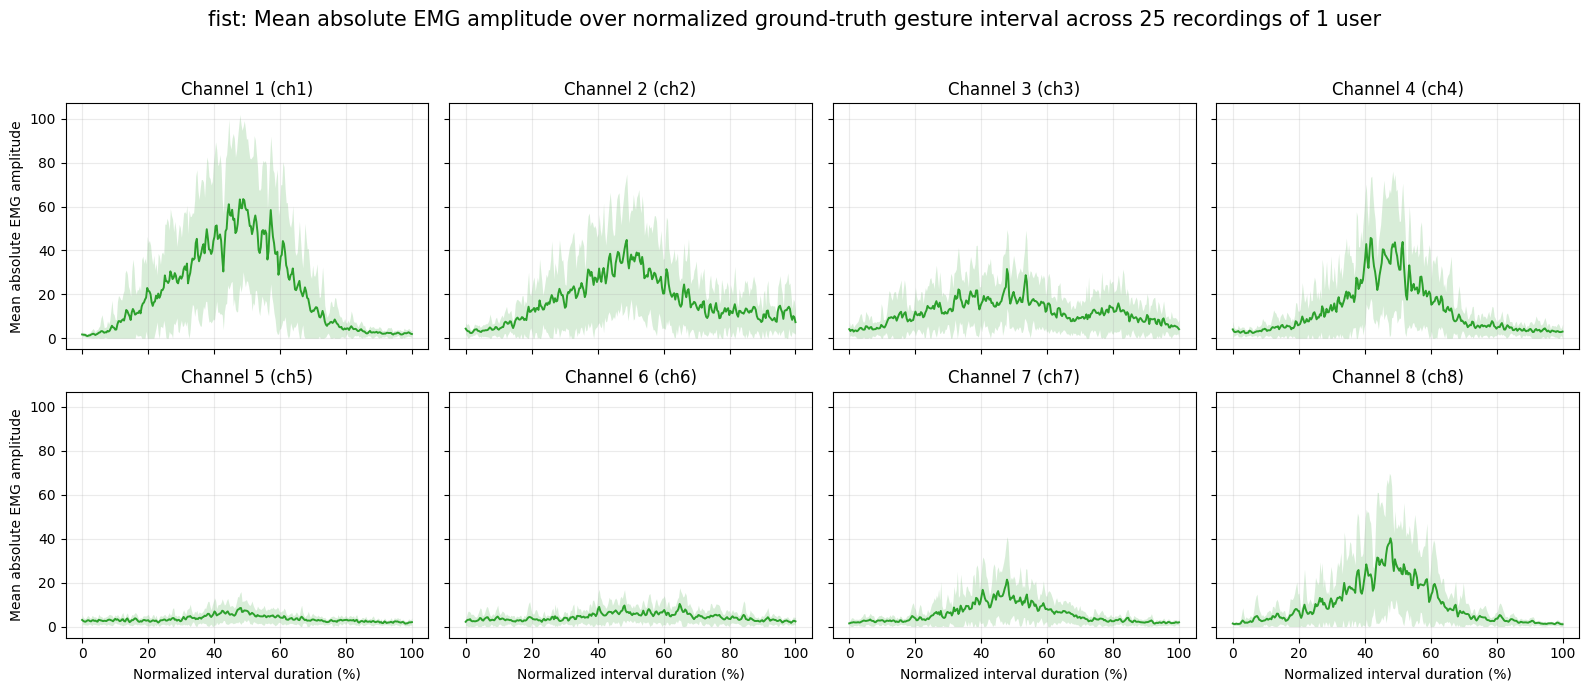

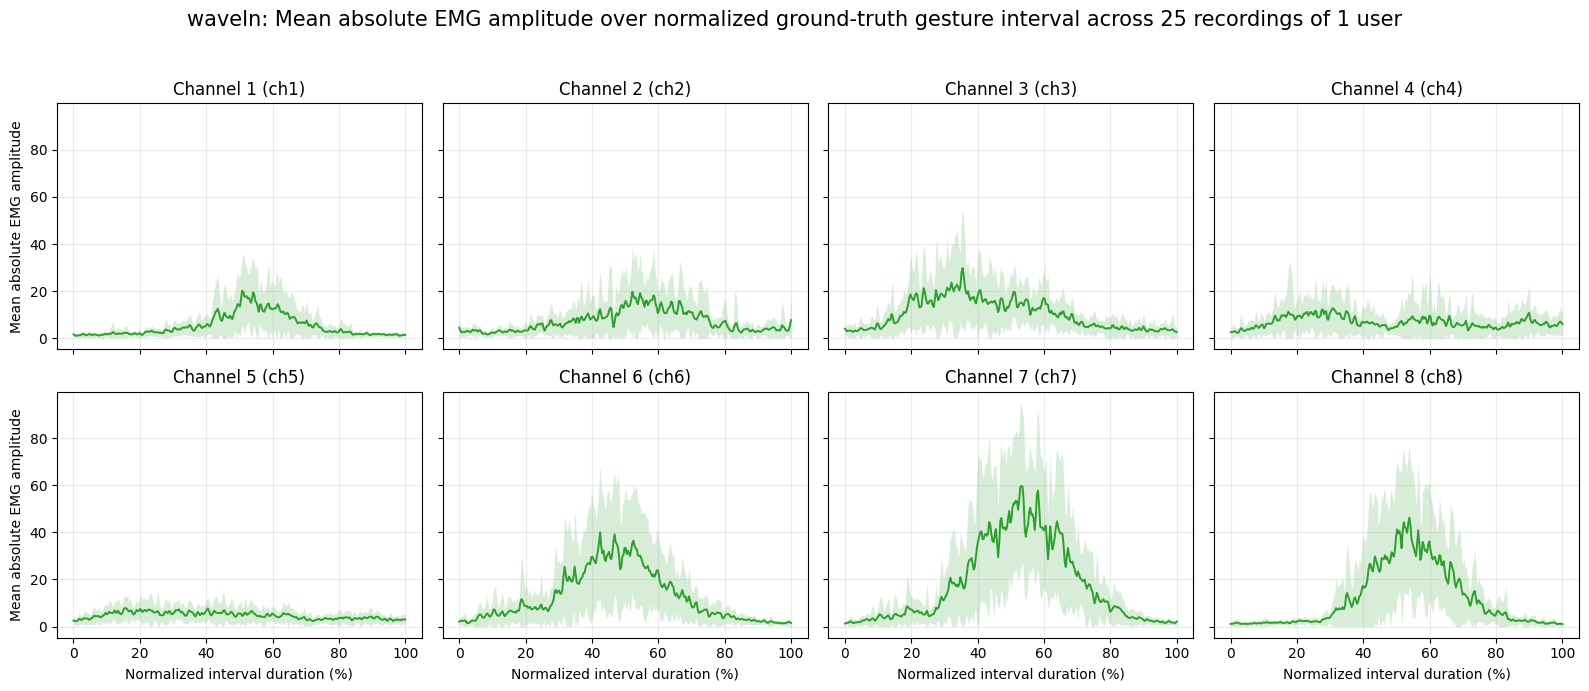

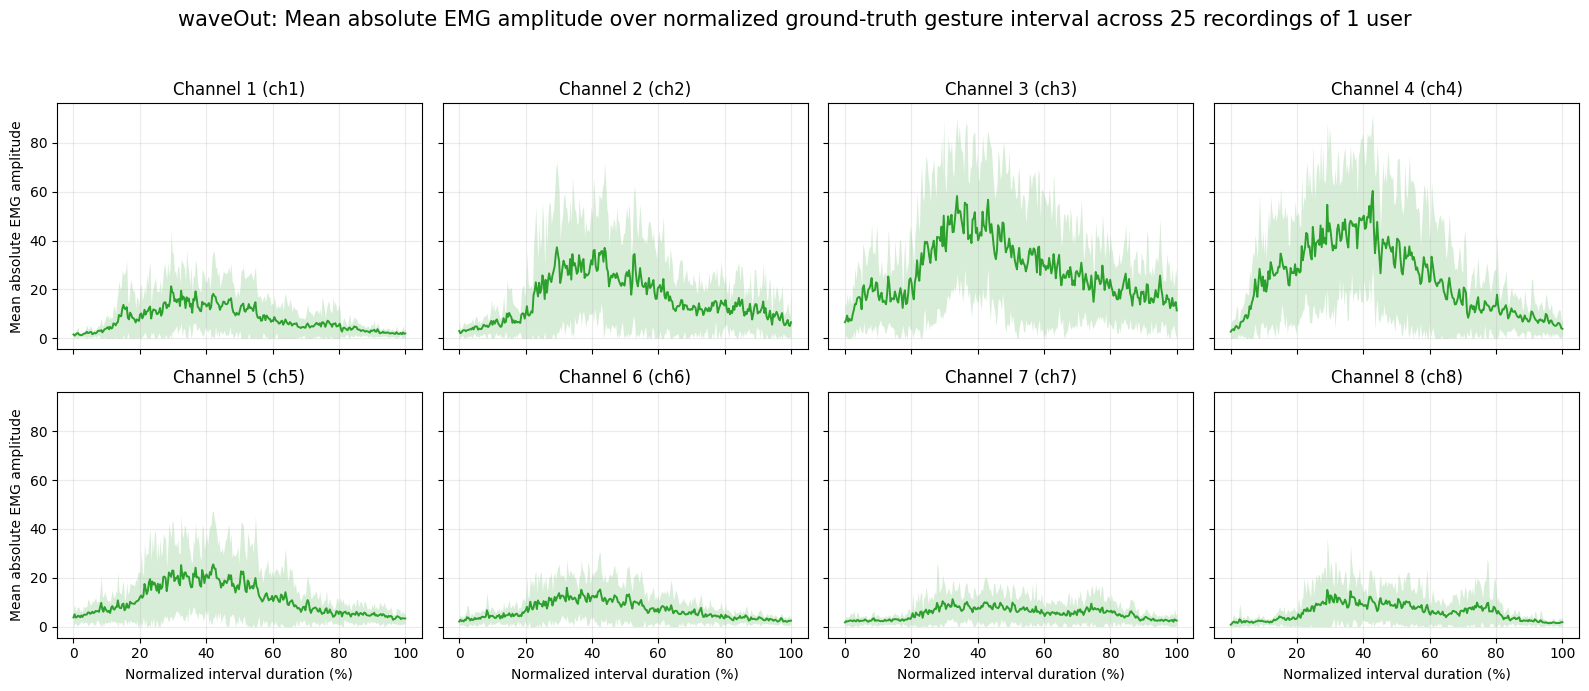

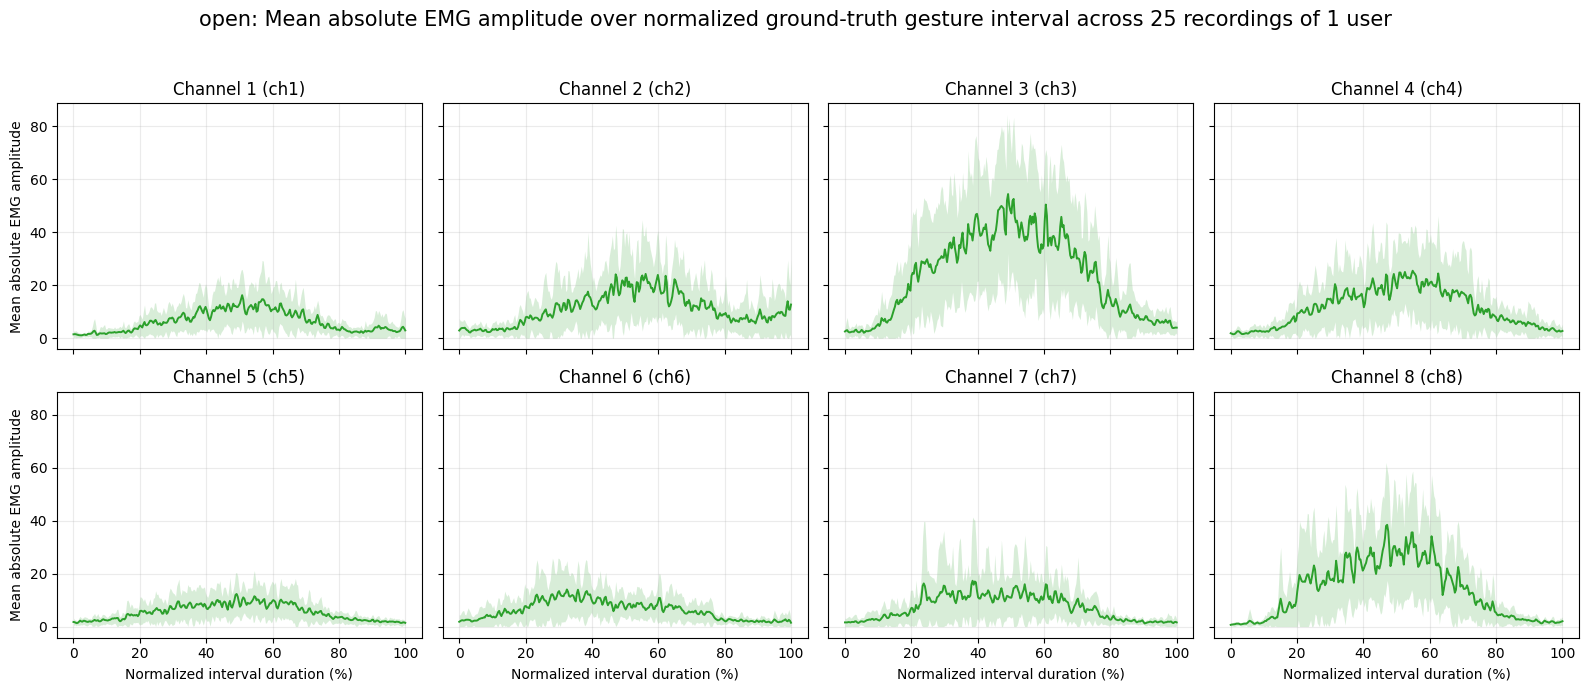

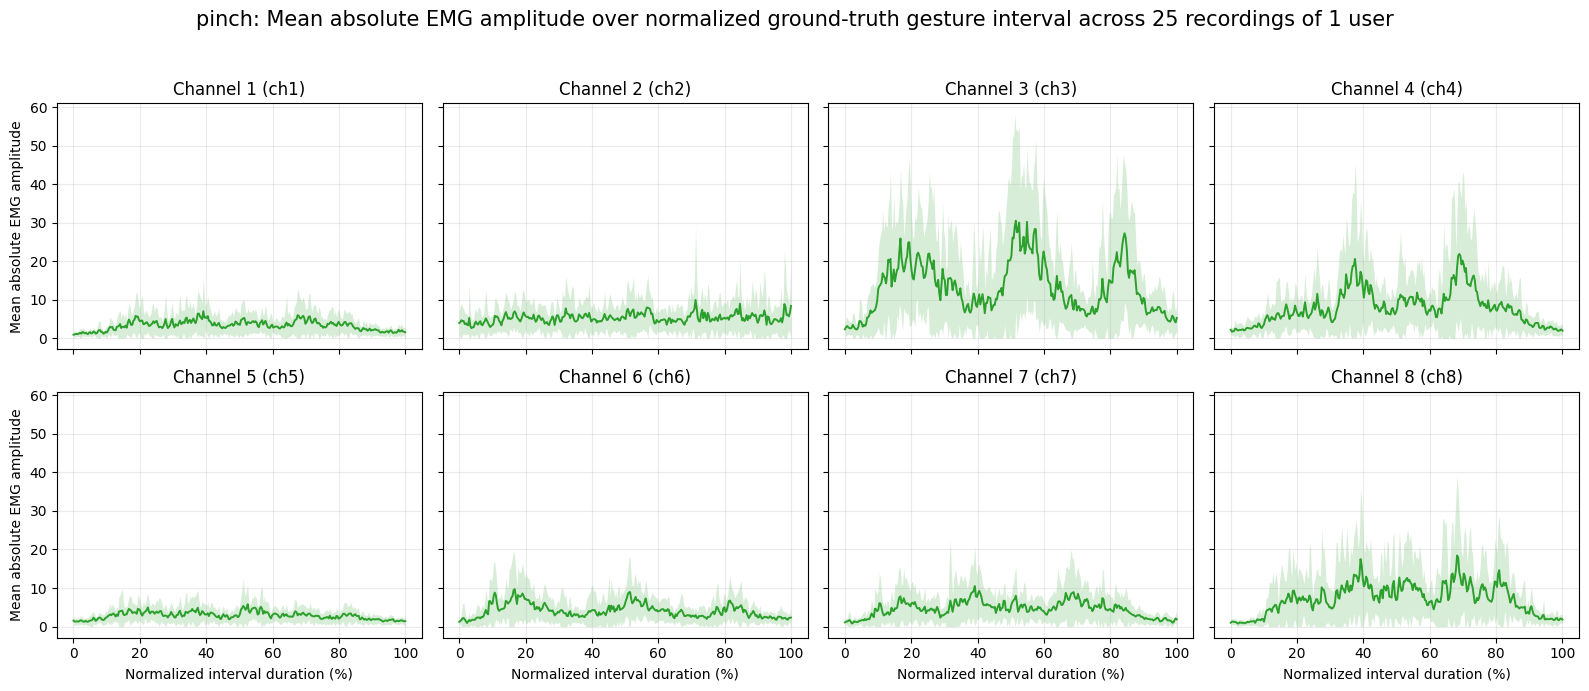

In [17]:
# One participant, using only the 25 recordings per gesture in trainingSamples.
TRAINING_ONLY_USER = 1
TRAINING_ONLY_NORMALIZED_POINTS = 300
TRAINING_ONLY_MIN_SEGMENT_SAMPLES = 20
TRAINING_ONLY_ABSOLUTE_EMG = True
TRAINING_ONLY_SHOW_STANDARD_DEVIATION = True

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

training_only_channels = [f'ch{i}' for i in range(1, 9)]
training_only_gesture_order = [
    'noGesture', 'fist', 'waveIn', 'waveOut', 'open', 'pinch'
]
training_only_path = (
    Path(EPN612_FOLDER)
    / 'trainingJSON'
    / f'user{TRAINING_ONLY_USER}'
    / f'user{TRAINING_ONLY_USER}.json'
)
if not training_only_path.is_file():
    raise FileNotFoundError(training_only_path)

print(f'Reading trainingSamples from {training_only_path}', flush=True)
with training_only_path.open(encoding='utf-8') as file:
    training_only_document = json.load(file)

training_only_name = training_only_document['userInfo']['name']
training_only_trials = training_only_document.get('trainingSamples', {})
print(
    f'Participant: {training_only_name} | '
    f'{len(training_only_trials)} trainingSamples recordings found',
    flush=True,
)

training_only_sums = {}
training_only_square_sums = {}
training_only_counts = Counter()
training_only_skipped = Counter()

for trial_id, trial in training_only_trials.items():
    gesture = trial.get('gestureName')
    if gesture is None:
        training_only_skipped['missing gestureName'] += 1
        continue

    try:
        channel_lengths = [
            len(trial['emg'][channel]) for channel in training_only_channels
        ]
    except (KeyError, TypeError):
        training_only_skipped['missing EMG channel'] += 1
        continue
    if len(set(channel_lengths)) != 1:
        training_only_skipped['unequal EMG channel lengths'] += 1
        continue

    try:
        signal = np.asarray(
            [trial['emg'][channel] for channel in training_only_channels],
            dtype=np.float64,
        )
    except (TypeError, ValueError):
        training_only_skipped['invalid EMG values'] += 1
        continue
    if not np.isfinite(signal).all():
        training_only_skipped['non-finite EMG values'] += 1
        continue

    sample_count = signal.shape[1]
    if gesture == 'noGesture':
        segment = signal
    else:
        ground_truth_index = trial.get('groundTruthIndex')
        ground_truth = trial.get('groundTruth')
        if not isinstance(ground_truth_index, list) or len(ground_truth_index) != 2:
            training_only_skipped['missing groundTruthIndex'] += 1
            continue
        if not isinstance(ground_truth, list) or len(ground_truth) != sample_count:
            training_only_skipped['missing or mismatched groundTruth'] += 1
            continue

        start_index_1based, end_index_1based = map(int, ground_truth_index)
        if not (1 <= start_index_1based <= end_index_1based <= sample_count):
            training_only_skipped['invalid groundTruthIndex'] += 1
            continue
        start_index = start_index_1based - 1
        end_index_exclusive = end_index_1based

        active_indexes = np.flatnonzero(np.asarray(ground_truth) != 0)
        if (
            active_indexes.size == 0
            or active_indexes[0] != start_index
            or active_indexes[-1] != end_index_exclusive - 1
        ):
            training_only_skipped['inconsistent ground-truth annotations'] += 1
            continue
        segment = signal[:, start_index:end_index_exclusive]

    if segment.shape[1] < TRAINING_ONLY_MIN_SEGMENT_SAMPLES:
        training_only_skipped['segment too short'] += 1
        continue
    if TRAINING_ONLY_ABSOLUTE_EMG:
        segment = np.abs(segment)

    source_phase = np.linspace(0.0, 1.0, segment.shape[1])
    target_phase = np.linspace(0.0, 1.0, TRAINING_ONLY_NORMALIZED_POINTS)
    normalized_signal = np.vstack([
        np.interp(target_phase, source_phase, channel_signal)
        for channel_signal in segment
    ])

    if gesture not in training_only_sums:
        shape = (len(training_only_channels), TRAINING_ONLY_NORMALIZED_POINTS)
        training_only_sums[gesture] = np.zeros(shape)
        training_only_square_sums[gesture] = np.zeros(shape)
    training_only_sums[gesture] += normalized_signal
    training_only_square_sums[gesture] += normalized_signal ** 2
    training_only_counts[gesture] += 1

used_recordings = sum(training_only_counts.values())
print(f'Usable trainingSamples recordings: {used_recordings}', flush=True)
print(f'Recordings per gesture: {dict(training_only_counts)}', flush=True)
print(f'Skipped by reason: {dict(training_only_skipped)}', flush=True)
if any(training_only_counts[g] != 25 for g in training_only_gesture_order):
    print('Warning: at least one gesture does not have exactly 25 usable recordings.', flush=True)

training_only_means = {}
training_only_standard_deviations = {}
for gesture, signal_sum in training_only_sums.items():
    count = training_only_counts[gesture]
    mean_signal = signal_sum / count
    variance = np.maximum(
        training_only_square_sums[gesture] / count - mean_signal ** 2,
        0,
    )
    training_only_means[gesture] = mean_signal
    training_only_standard_deviations[gesture] = np.sqrt(variance)

phase_percent = np.linspace(0.0, 100.0, TRAINING_ONLY_NORMALIZED_POINTS)
quantity_name = (
    'Mean absolute EMG amplitude'
    if TRAINING_ONLY_ABSOLUTE_EMG
    else 'Mean signed EMG'
)
for gesture in training_only_gesture_order:
    if gesture not in training_only_means:
        continue
    mean_emg = training_only_means[gesture]
    standard_deviation = training_only_standard_deviations[gesture]
    interval_name = (
        'full rest recording'
        if gesture == 'noGesture'
        else 'ground-truth gesture interval'
    )
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
    for channel_index, (axis, channel) in enumerate(
        zip(axes.flat, training_only_channels)
    ):
        channel_mean = mean_emg[channel_index]
        channel_std = standard_deviation[channel_index]
        axis.plot(phase_percent, channel_mean, linewidth=1.4, color='C2')
        if TRAINING_ONLY_SHOW_STANDARD_DEVIATION:
            lower = channel_mean - channel_std
            if TRAINING_ONLY_ABSOLUTE_EMG:
                lower = np.maximum(lower, 0)
            axis.fill_between(
                phase_percent, lower, channel_mean + channel_std,
                color='C2', alpha=0.18, linewidth=0,
            )
        axis.set_title(f'Channel {channel_index + 1} ({channel})')
        axis.grid(alpha=0.25)
        if channel_index // 4 == 1:
            axis.set_xlabel('Normalized interval duration (%)')
        if channel_index % 4 == 0:
            axis.set_ylabel(quantity_name)
    fig.suptitle(
        f'{gesture}: '
        f'{quantity_name} over normalized {interval_name} across '
        f'{training_only_counts[gesture]} recordings of 1 user',
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
